> Note: Dataset dari KLH yang digunakan merupakan dataset 2021-2023.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [50]:
print(Path.cwd())

d:\Kuliah\Tugas Akhir\TA


# Load Main Dataset

In [51]:
data_dir = Path(r"D:\Kuliah\Tugas Akhir\TA\dataset\LHCLEAN")

years = [2021, 2022, 2023]
months = list(range(1, 13))

dfs = []

for year in years:
    for month in months:
        file = f"{year}_{month}.xlsx"
        path = data_dir / file

        print("Loading:", file)

        df_month = pd.read_excel(path, sheet_name="Worksheet")
        df_month.columns = df_month.columns.astype(str).str.strip()

        df_month = df_month[["Waktu", "PM2.5", "Anomaly"]].copy()

        df_month = df_month.rename(columns={
            "Waktu": "datetime",
            "PM2.5": "pm25",
            "Anomaly": "label"
        })

        df_month["datetime"] = pd.to_datetime(df_month["datetime"], errors="coerce")
        df_month["pm25"] = pd.to_numeric(df_month["pm25"], errors="coerce")
        df_month["label"] = pd.to_numeric(df_month["label"], errors="coerce")

        df_month = df_month.dropna(subset=["datetime", "pm25", "label"]).copy()

        df_month["label"] = df_month["label"].astype(int)
        df_month["year_file"] = year
        df_month["month_file"] = month
        df_month["source_file"] = file

        dfs.append(df_month)

df_clean = pd.concat(dfs, ignore_index=True)
df_clean = df_clean.sort_values("datetime").reset_index(drop=True)

print("Shape:", df_clean.shape)
print(df_clean.head())
print(df_clean["label"].value_counts(dropna=False))

Loading: 2021_1.xlsx
Loading: 2021_2.xlsx
Loading: 2021_3.xlsx
Loading: 2021_4.xlsx
Loading: 2021_5.xlsx
Loading: 2021_6.xlsx
Loading: 2021_7.xlsx
Loading: 2021_8.xlsx
Loading: 2021_9.xlsx
Loading: 2021_10.xlsx
Loading: 2021_11.xlsx
Loading: 2021_12.xlsx
Loading: 2022_1.xlsx
Loading: 2022_2.xlsx
Loading: 2022_3.xlsx
Loading: 2022_4.xlsx
Loading: 2022_5.xlsx
Loading: 2022_6.xlsx
Loading: 2022_7.xlsx
Loading: 2022_8.xlsx
Loading: 2022_9.xlsx
Loading: 2022_10.xlsx
Loading: 2022_11.xlsx
Loading: 2022_12.xlsx
Loading: 2023_1.xlsx
Loading: 2023_2.xlsx
Loading: 2023_3.xlsx
Loading: 2023_4.xlsx
Loading: 2023_5.xlsx
Loading: 2023_6.xlsx
Loading: 2023_7.xlsx
Loading: 2023_8.xlsx
Loading: 2023_9.xlsx
Loading: 2023_10.xlsx
Loading: 2023_11.xlsx
Loading: 2023_12.xlsx
Shape: (50972, 6)
             datetime  pm25  label  year_file  month_file  source_file
0 2021-01-01 00:00:00    22      0       2021           1  2021_1.xlsx
1 2021-01-01 00:30:00    28      0       2021           1  2021_1.xlsx
2 20

In [52]:
# Descriptive statistics PM2.5 dari df_clean
pm25_stats = df_clean["pm25"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
)

display(
    pm25_stats.to_frame(
        name="PM2.5"
    )
)

print("PM2.5 Max :", df_clean["pm25"].max())
print("Variance :", df_clean["pm25"].var())
print("Skewness :", df_clean["pm25"].skew())
print("Kurtosis :", df_clean["pm25"].kurt())
print("Missing  :", df_clean["pm25"].isna().sum())

,PM2.5
count,50972.000000
mean,38.754708
std,323.891200
min,0.000000
25%,17.000000
50%,29.000000
75%,48.000000
90%,71.000000
95%,89.000000
99%,139.000000


PM2.5 Max : 67601
Variance : 104905.50948813971
Skewness : 185.88766417803944
Kurtosis : 37629.73098197891
Missing  : 0


In [53]:
print("Jumlah baris:", len(df_clean))
print("Datetime min:", df_clean["datetime"].min())
print("Datetime max:", df_clean["datetime"].max())
print("Datetime kosong:", df_clean["datetime"].isna().sum())
print("PM2.5 kosong:", df_clean["pm25"].isna().sum())
print("Label kosong:", df_clean["label"].isna().sum())
print("Duplikat datetime:", df_clean["datetime"].duplicated().sum())

print("\nDistribusi label:")
print(df_clean["label"].value_counts(dropna=False))

Jumlah baris: 50972
Datetime min: 2021-01-01 00:00:00
Datetime max: 2023-12-31 23:30:00
Datetime kosong: 0
PM2.5 kosong: 0
Label kosong: 0
Duplikat datetime: 0

Distribusi label:
label
0    50049
1      923
Name: count, dtype: int64


## Check Timestamp

Off-grid timestamp rows: 2


,datetime,pm25,label,year_file,month_file,source_file
27391,2022-08-18 20:15:00,0,0,2022,8,2022_8.xlsx
27393,2022-08-18 20:45:00,0,0,2022,8,2022_8.xlsx


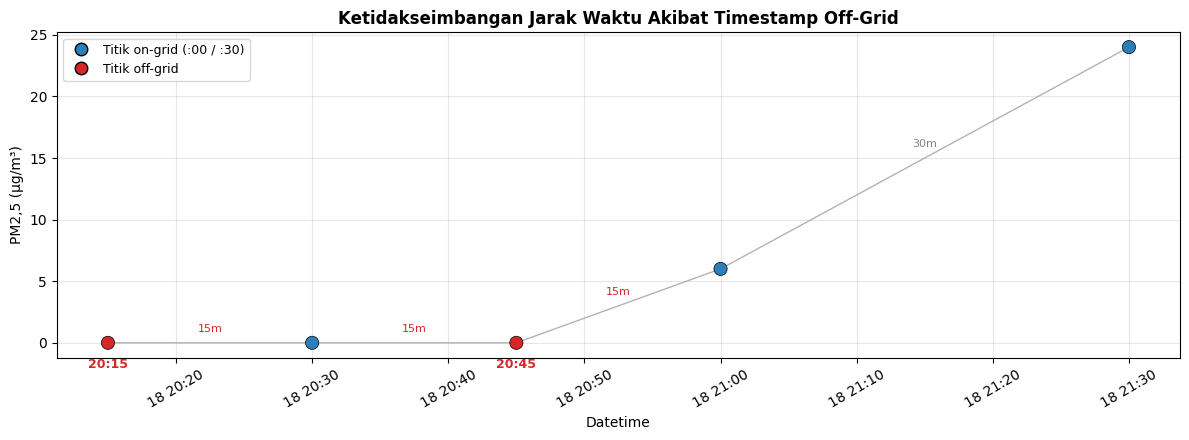

Rows after dropping off-grid: 50970


In [54]:
off_grid_mask = ~(
    df_clean["datetime"].dt.minute.isin([0, 30]) &
    (df_clean["datetime"].dt.second == 0)
)

off_grid_rows = df_clean[off_grid_mask].copy()

print("Off-grid timestamp rows:", len(off_grid_rows))
display(off_grid_rows)

# =========================================================
# Plot: ketidakseimbangan jarak waktu akibat timestamp off-grid
# =========================================================
from matplotlib.lines import Line2D

# Ambil konteks di sekitar timestamp off-grid pertama
anchor = off_grid_rows["datetime"].iloc[0]
lo = anchor - pd.Timedelta(hours=1, minutes=30)
hi = anchor + pd.Timedelta(hours=1, minutes=30)

ctx = df_clean[(df_clean["datetime"] >= lo) & (df_clean["datetime"] <= hi)].copy()
ctx = ctx.sort_values("datetime").reset_index(drop=True)
ctx["is_offgrid"] = ~(
    ctx["datetime"].dt.minute.isin([0, 30]) & (ctx["datetime"].dt.second == 0)
)

fig, ax = plt.subplots(figsize=(12, 4.5))

colors = ["#d62728" if og else "#2c7fb8" for og in ctx["is_offgrid"]]
ax.plot(ctx["datetime"], ctx["pm25"], color="gray", linewidth=1, alpha=0.6, zorder=1)
ax.scatter(ctx["datetime"], ctx["pm25"], c=colors, s=90, zorder=3,
           edgecolor="black", linewidth=0.5)

# Anotasi selisih menit antar titik berurutan
for i in range(1, len(ctx)):
    t_prev = ctx.loc[i - 1, "datetime"]
    t_now = ctx.loc[i, "datetime"]
    gap = (t_now - t_prev).total_seconds() / 60
    x_mid = t_prev + (t_now - t_prev) / 2
    y_mid = (ctx.loc[i - 1, "pm25"] + ctx.loc[i, "pm25"]) / 2
    warna = "#d62728" if gap != 30 else "gray"
    ax.annotate(f"{gap:.0f}m", (x_mid, y_mid), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=warna)

# Label jam pada titik off-grid
for _, row in ctx[ctx["is_offgrid"]].iterrows():
    ax.annotate(row["datetime"].strftime("%H:%M"), (row["datetime"], row["pm25"]),
                textcoords="offset points", xytext=(0, -18), ha="center",
                fontsize=9, color="#d62728", fontweight="bold")

ax.set_title("Ketidakseimbangan Jarak Waktu Akibat Timestamp Off-Grid",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Datetime")
ax.set_ylabel("PM2,5 (μg/m³)")

legend_el = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2c7fb8",
           markeredgecolor="black", label="Titik on-grid (:00 / :30)", markersize=9),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markeredgecolor="black", label="Titik off-grid", markersize=9),
]
ax.legend(handles=legend_el, fontsize=9)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Drop off-grid timestamp karena data target adalah grid 30 menit.
df_clean = df_clean[~off_grid_mask].copy()
df_clean = df_clean.sort_values("datetime").reset_index(drop=True)

print("Rows after dropping off-grid:", len(df_clean))

In [55]:
dup = df_clean[df_clean["datetime"].duplicated(keep=False)].copy()

print("Duplicate datetime rows:", len(dup))
display(dup.sort_values("datetime").head(20))

# Kalau ternyata ada duplikat, pakai agregasi konservatif.
if len(dup) > 0:
    df_clean = (
        df_clean
        .groupby("datetime", as_index=False)
        .agg(
            pm25=("pm25", "mean"),
            label=("label", "max"),
            source_file=("source_file", lambda x: ",".join(sorted(set(x.astype(str)))))
        )
    )

df_clean = df_clean.sort_values("datetime").reset_index(drop=True)

print("Rows after duplicate handling:", len(df_clean))
print("Duplicate datetime:", df_clean["datetime"].duplicated().sum())

Duplicate datetime rows: 0


,datetime,pm25,label,year_file,month_file,source_file


Rows after duplicate handling: 50970
Duplicate datetime: 0


## Reindexing

In [56]:
full_time = pd.date_range(
    start="2021-01-01 00:00:00",
    end="2023-12-31 23:30:00",
    freq="30min"
)

df_full = (
    df_clean
    .set_index("datetime")
    .reindex(full_time)
    .rename_axis("datetime")
    .reset_index()
)

df_full["is_missing_timestamp"] = df_full["pm25"].isna().astype(int)

# Timestamp hasil reindex tidak punya ground truth label.
df_full["label_original"] = df_full["label"]
df_full["label_eval"] = df_full["label_original"]
df_full.loc[df_full["is_missing_timestamp"] == 1, "label_eval"] = np.nan

# Drop kolom label lama supaya tidak ambigu
df_full = df_full.drop(columns=["label"])

print("Expected rows:", len(full_time))
print("Rows after reindex:", len(df_full))
print("Missing timestamp:", df_full["is_missing_timestamp"].sum())
print("Anomaly count:", df_full["label_eval"].sum(skipna=True))
print("PM2.5 missing:", df_full["pm25"].isna().sum())
print("Label eval missing:", df_full["label_eval"].isna().sum())

Expected rows: 52560
Rows after reindex: 52560
Missing timestamp: 1590
Anomaly count: 923.0
PM2.5 missing: 1590
Label eval missing: 1590


# Missing values run checking

In [57]:
SHORT_GAP_LIMIT = 12  # 12 titik = 6 jam

df_full = df_full.sort_values("datetime").reset_index(drop=True)

df_full["missing_run_id"] = np.nan
df_full["missing_run_len"] = 0

missing = df_full[df_full["is_missing_timestamp"] == 1].copy()

if not missing.empty:
    missing["missing_run_id"] = (
        missing["datetime"].diff().ne(pd.Timedelta(minutes=30))
    ).cumsum()
    
    run_len_map = missing.groupby("missing_run_id").size()
    missing["missing_run_len"] = missing["missing_run_id"].map(run_len_map)
    
    df_full.loc[missing.index, "missing_run_id"] = missing["missing_run_id"]
    df_full.loc[missing.index, "missing_run_len"] = missing["missing_run_len"]

df_full["is_long_gap"] = (
    (df_full["is_missing_timestamp"] == 1) &
    (df_full["missing_run_len"] > SHORT_GAP_LIMIT)
).astype(int)

print("Total missing:", df_full["is_missing_timestamp"].sum())
print("Long-gap missing:", df_full["is_long_gap"].sum())
print("Short-gap missing:", ((df_full["is_missing_timestamp"] == 1) & (df_full["is_long_gap"] == 0)).sum())

Total missing: 1590
Long-gap missing: 1372
Short-gap missing: 218


# Static/Flatline Checking

In [58]:
STATIC_ZERO_LIMIT = 2
STATIC_NONZERO_LIMIT = 4

def add_flatline_flags(df, value_col="pm25"):
    df = df.copy()
    df = df.sort_values("datetime").reset_index(drop=True)

    observed = df[value_col].notna()

    same_value = df[value_col].eq(df[value_col].shift())
    consecutive_time = df["datetime"].diff().eq(pd.Timedelta(minutes=30))
    both_observed = observed & observed.shift(fill_value=False)

    # Run baru jika:
    # - nilai berubah
    # - waktu tidak berurutan 30 menit
    # - salah satu titik missing
    new_flat_run = ~(same_value & consecutive_time & both_observed)

    df["flat_run_id"] = new_flat_run.cumsum()

    # Missing timestamp tidak dihitung sebagai flatline
    df.loc[~observed, "flat_run_id"] = np.nan

    df["flat_run_len"] = 0
    df["flat_pos_in_run"] = 0

    # Panjang run
    df.loc[observed, "flat_run_len"] = (
        df.loc[observed]
        .groupby("flat_run_id")[value_col]
        .transform("size")
        .astype(int)
    )

    # Posisi titik di dalam run: 1, 2, 3, ...
    df.loc[observed, "flat_pos_in_run"] = (
        df.loc[observed]
        .groupby("flat_run_id")
        .cumcount()
        .add(1)
        .astype(int)
    )

    # Static zero 
    df["is_zero_flatline"] = (
        (df[value_col] == 0) &
        (df["flat_run_len"] >= STATIC_ZERO_LIMIT)
    ).astype(int)

    # Static non-zero >= Limit
    # Catatan: non-zero static run tidak dihapus semua, hanya titik setelah limit yang dihapus
    df["is_nonzero_flatline"] = (
        (df[value_col] != 0) &
        df[value_col].notna() &
        (df["flat_run_len"] >= STATIC_NONZERO_LIMIT)
    ).astype(int)

    df["is_long_flatline"] = (
        (df["is_zero_flatline"] == 1) |
        (df["is_nonzero_flatline"] == 1)
    ).astype(int)

    return df

df_full = add_flatline_flags(df_full, value_col="pm25")

print("Zero flatline points:", df_full["is_zero_flatline"].sum())
print("Non-zero flatline points:", df_full["is_nonzero_flatline"].sum())
print("All flatline points:", df_full["is_long_flatline"].sum())

Zero flatline points: 57
Non-zero flatline points: 1347
All flatline points: 1404


In [59]:
# ALL FLAT RUN ENTITIES
all_flat_runs = (
    df_full
    .groupby("flat_run_id", as_index=False)
    .agg(
        start_datetime=("datetime", "min"),
        end_datetime=("datetime", "max"),
        pm25_value=("pm25", "first"),
        n_points=("datetime", "size"),
        flat_run_len=("flat_run_len", "max"),
        is_zero_flatline=("is_zero_flatline", "max"),
        is_nonzero_flatline=("is_nonzero_flatline", "max")
    )
    .sort_values("start_datetime")
    .reset_index(drop=True)
)

all_flat_runs["duration_hours"] = (
    all_flat_runs["n_points"] * 0.5
)

display(all_flat_runs)

,flat_run_id,start_datetime,end_datetime,pm25_value,n_points,flat_run_len,is_zero_flatline,is_nonzero_flatline,duration_hours
0,1.0,2021-01-01 00:00:00,2021-01-01 00:00:00,22.0,1,1,0,0,0.5
1,2.0,2021-01-01 00:30:00,2021-01-01 00:30:00,28.0,1,1,0,0,0.5
2,3.0,2021-01-01 01:00:00,2021-01-01 01:00:00,36.0,1,1,0,0,0.5
3,4.0,2021-01-01 01:30:00,2021-01-01 02:30:00,35.0,3,3,0,0,1.5
4,5.0,2021-01-01 03:00:00,2021-01-01 03:00:00,29.0,1,1,0,0,0.5
...,...,...,...,...,...,...,...,...,...
44568,46159.0,2023-12-31 21:30:00,2023-12-31 21:30:00,20.0,1,1,0,0,0.5
44569,46160.0,2023-12-31 22:00:00,2023-12-31 22:00:00,21.0,1,1,0,0,0.5
44570,46161.0,2023-12-31 22:30:00,2023-12-31 22:30:00,26.0,1,1,0,0,0.5
44571,46162.0,2023-12-31 23:00:00,2023-12-31 23:00:00,47.0,1,1,0,0,0.5


## Static Zero Checking

In [60]:
# ALL STATIC-ZERO POINTS
static_zero_points = df_full.loc[
    df_full["is_zero_flatline"] == 1,
    [
        "datetime",
        "pm25",
        "flat_run_id",
        "flat_run_len",
        "flat_pos_in_run"
    ]
].copy()

print("Jumlah static-zero points:", len(static_zero_points))

display(static_zero_points)

Jumlah static-zero points: 57


,datetime,pm25,flat_run_id,flat_run_len,flat_pos_in_run
33634,2022-12-02 17:00:00,0.0,29198.0,6,1
33635,2022-12-02 17:30:00,0.0,29198.0,6,2
33636,2022-12-02 18:00:00,0.0,29198.0,6,3
33637,2022-12-02 18:30:00,0.0,29198.0,6,4
33638,2022-12-02 19:00:00,0.0,29198.0,6,5
33639,2022-12-02 19:30:00,0.0,29198.0,6,6
47702,2023-09-21 19:00:00,0.0,41827.0,2,1
47703,2023-09-21 19:30:00,0.0,41827.0,2,2
47861,2023-09-25 02:30:00,0.0,41973.0,2,1
47862,2023-09-25 03:00:00,0.0,41973.0,2,2


In [61]:
# STATIC-ZERO POINTS AND RUN ENTITIES
static_zero_points = (
    df_full.loc[
        df_full["is_zero_flatline"] == 1,
        [
            "datetime",
            "pm25",
            "flat_run_id",
            "flat_run_len",
            "flat_pos_in_run"
        ]
    ]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

static_zero_runs = (
    static_zero_points
    .groupby("flat_run_id", as_index=False)
    .agg(
        start_datetime=("datetime", "min"),
        end_datetime=("datetime", "max"),
        n_points=("datetime", "size"),
        pm25_value=("pm25", "first")
    )
    .sort_values("start_datetime")
    .reset_index(drop=True)
)

# ID khusus static-zero, dimulai dari 1
static_zero_runs.insert(
    0,
    "zero_run_entity_id",
    np.arange(1, len(static_zero_runs) + 1)
)

# Durasi dari timestamp pertama sampai terakhir ditambah satu interval
static_zero_runs["duration_hours"] = (
    static_zero_runs["n_points"] * 0.5
)

print(
    "Jumlah static-zero points      :",
    len(static_zero_points)
)
print(
    "Jumlah static-zero run entities:",
    len(static_zero_runs)
)

display(static_zero_runs)

Jumlah static-zero points      : 57
Jumlah static-zero run entities: 7


,zero_run_entity_id,flat_run_id,start_datetime,end_datetime,n_points,pm25_value,duration_hours
0,1,29198.0,2022-12-02 17:00:00,2022-12-02 19:30:00,6,0.0,3.0
1,2,41827.0,2023-09-21 19:00:00,2023-09-21 19:30:00,2,0.0,1.0
2,3,41973.0,2023-09-25 02:30:00,2023-09-25 03:00:00,2,0.0,1.0
3,4,42065.0,2023-09-27 06:30:00,2023-09-27 07:00:00,2,0.0,1.0
4,5,42184.0,2023-09-29 21:30:00,2023-09-29 22:00:00,2,0.0,1.0
5,6,42201.0,2023-09-30 07:00:00,2023-09-30 08:00:00,3,0.0,1.5
6,7,42213.0,2023-09-30 14:00:00,2023-10-01 09:30:00,40,0.0,20.0


In [62]:
# SELECT ONE STATIC-ZERO RUN EXAMPLE
ZERO_EXAMPLE_ID = 1

selected_zero_entity = static_zero_runs.loc[
    static_zero_runs["zero_run_entity_id"]
    == ZERO_EXAMPLE_ID
]

if selected_zero_entity.empty:
    print(
        f"Static-zero entity ID {ZERO_EXAMPLE_ID} "
        "tidak ditemukan."
    )

else:
    selected_zero_entity = selected_zero_entity.iloc[0]

    selected_flat_run_id = (
        selected_zero_entity["flat_run_id"]
    )

    example_static_zero_run = (
        df_full.loc[
            df_full["flat_run_id"]
            == selected_flat_run_id,
            [
                "datetime",
                "pm25",
                "flat_run_id",
                "flat_run_len",
                "flat_pos_in_run",
                "is_zero_flatline"
            ]
        ]
        .copy()
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    print("Static-zero example")
    print("Entity ID    :", ZERO_EXAMPLE_ID)
    print("flat_run_id  :", selected_flat_run_id)
    print(
        "Start        :",
        selected_zero_entity["start_datetime"]
    )
    print(
        "End          :",
        selected_zero_entity["end_datetime"]
    )
    print(
        "Number points:",
        int(selected_zero_entity["n_points"])
    )
    print(
        "Duration     :",
        selected_zero_entity["duration_hours"],
        "hours"
    )

    display(example_static_zero_run)

Static-zero example
Entity ID    : 1
flat_run_id  : 29198.0
Start        : 2022-12-02 17:00:00
End          : 2022-12-02 19:30:00
Number points: 6
Duration     : 3.0 hours


,datetime,pm25,flat_run_id,flat_run_len,flat_pos_in_run,is_zero_flatline
0,2022-12-02 17:00:00,0.0,29198.0,6,1,1
1,2022-12-02 17:30:00,0.0,29198.0,6,2,1
2,2022-12-02 18:00:00,0.0,29198.0,6,3,1
3,2022-12-02 18:30:00,0.0,29198.0,6,4,1
4,2022-12-02 19:00:00,0.0,29198.0,6,5,1
5,2022-12-02 19:30:00,0.0,29198.0,6,6,1


## Static Non Zero Checking

In [63]:
# STATIC NON-ZERO POINTS AND RUN ENTITIES
static_nonzero_points = (
    df_full.loc[
        df_full["is_nonzero_flatline"] == 1,
        [
            "datetime",
            "pm25",
            "flat_run_id",
            "flat_run_len",
            "flat_pos_in_run"
        ]
    ]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

static_nonzero_runs = (
    static_nonzero_points
    .groupby("flat_run_id", as_index=False)
    .agg(
        start_datetime=("datetime", "min"),
        end_datetime=("datetime", "max"),
        n_points=("datetime", "size"),
        pm25_value=("pm25", "first")
    )
    .sort_values("start_datetime")
    .reset_index(drop=True)
)

# ID khusus static non-zero, dimulai dari 1
static_nonzero_runs.insert(
    0,
    "nonzero_run_entity_id",
    np.arange(1, len(static_nonzero_runs) + 1)
)

static_nonzero_runs["duration_hours"] = (
    static_nonzero_runs["n_points"] * 0.5
)

print(
    "Jumlah static non-zero points      :",
    len(static_nonzero_points)
)
print(
    "Jumlah static non-zero run entities:",
    len(static_nonzero_runs)
)
# non zero run entities
display(static_nonzero_runs)

Jumlah static non-zero points      : 1347
Jumlah static non-zero run entities: 219


,nonzero_run_entity_id,flat_run_id,start_datetime,end_datetime,n_points,pm25_value,duration_hours
0,1,242.0,2021-01-06 22:30:00,2021-01-07 00:00:00,4,20.0,2.0
1,2,251.0,2021-01-07 06:30:00,2021-01-07 08:30:00,5,5.0,2.5
2,3,258.0,2021-01-07 14:00:00,2021-01-07 16:00:00,5,5.0,2.5
3,4,351.0,2021-01-10 02:30:00,2021-01-10 04:00:00,4,7.0,2.0
4,5,361.0,2021-01-10 10:00:00,2021-01-10 12:00:00,5,4.0,2.5
...,...,...,...,...,...,...,...
214,215,45407.0,2023-12-14 02:30:00,2023-12-14 04:30:00,5,21.0,2.5
215,216,45448.0,2023-12-15 03:30:00,2023-12-15 05:00:00,4,19.0,2.0
216,217,45475.0,2023-12-15 20:30:00,2023-12-15 22:00:00,4,23.0,2.0
217,218,45669.0,2023-12-20 12:30:00,2023-12-20 14:00:00,4,14.0,2.0


In [64]:
# ALL STATIC NON-ZERO POINTS
static_nonzero_points = df_full.loc[
    df_full["is_nonzero_flatline"] == 1,
    [
        "datetime",
        "pm25",
        "flat_run_id",
        "flat_run_len",
        "flat_pos_in_run"
    ]
].copy()

print(
    "Jumlah static non-zero points:",
    len(static_nonzero_points)
)

display(static_nonzero_points)

Jumlah static non-zero points: 1347


,datetime,pm25,flat_run_id,flat_run_len,flat_pos_in_run
285,2021-01-06 22:30:00,20.0,242.0,4,1
286,2021-01-06 23:00:00,20.0,242.0,4,2
287,2021-01-06 23:30:00,20.0,242.0,4,3
288,2021-01-07 00:00:00,20.0,242.0,4,4
301,2021-01-07 06:30:00,5.0,251.0,5,1
...,...,...,...,...,...
52012,2023-12-20 14:00:00,14.0,45669.0,4,4
52308,2023-12-26 18:00:00,12.0,45932.0,4,1
52309,2023-12-26 18:30:00,12.0,45932.0,4,2
52310,2023-12-26 19:00:00,12.0,45932.0,4,3


In [ ]:
# SELECT ONE STATIC NON-ZERO RUN EXAMPLE
NONZERO_EXAMPLE_ID = 1

selected_nonzero_entity = static_nonzero_runs.loc[
    static_nonzero_runs["nonzero_run_entity_id"]
    == NONZERO_EXAMPLE_ID
]

if selected_nonzero_entity.empty:
    print(
        f"Static non-zero entity ID "
        f"{NONZERO_EXAMPLE_ID} tidak ditemukan."
    )

else:
    selected_nonzero_entity = (
        selected_nonzero_entity.iloc[0]
    )

    selected_flat_run_id = (
        selected_nonzero_entity["flat_run_id"]
    )

    example_static_nonzero_run = (
        df_full.loc[
            df_full["flat_run_id"]
            == selected_flat_run_id,
            [
                "datetime",
                "pm25",
                "flat_run_id",
                "flat_run_len",
                "flat_pos_in_run",
                "is_nonzero_flatline"
            ]
        ]
        .copy()
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    print("Static non-zero example")
    print("Entity ID    :", NONZERO_EXAMPLE_ID)
    print("flat_run_id  :", selected_flat_run_id)
    print(
        "Static value :",
        selected_nonzero_entity["pm25_value"]
    )
    print(
        "Start        :",
        selected_nonzero_entity[
            "start_datetime"
        ]
    )
    print(
        "End          :",
        selected_nonzero_entity[
            "end_datetime"
        ]
    )
    print(
        "Number points:",
        int(selected_nonzero_entity["n_points"])
    )
    print(
        "Duration     :",
        selected_nonzero_entity[
            "duration_hours"
        ],
        "hours"
    )

    display(example_static_nonzero_run)

Static non-zero example
Entity ID    : 1
flat_run_id  : 242.0
Static value : 20.0
Start        : 2021-01-06 22:30:00
End          : 2021-01-07 00:00:00
Number points: 4
Duration     : 2.0 hours


,datetime,pm25,flat_run_id,flat_run_len,flat_pos_in_run,is_nonzero_flatline
0,2021-01-06 22:30:00,20.0,242.0,4,1,1
1,2021-01-06 23:00:00,20.0,242.0,4,2,1
2,2021-01-06 23:30:00,20.0,242.0,4,3,1
3,2021-01-07 00:00:00,20.0,242.0,4,4,1


# Extreme values Checking

In [ ]:
# Cek nilai PM2.5 tertinggi untuk dfclean (df before reindex)
top_high = df_clean.sort_values("pm25", ascending=False)[
    ["datetime", "pm25", "label", "source_file"]
].head(50)

top_high

,datetime,pm25,label,source_file
15965,2021-12-08 15:30:00,67601,1,2021_12.xlsx
15964,2021-12-08 15:00:00,22284,1,2021_12.xlsx
15966,2021-12-08 16:00:00,11001,1,2021_12.xlsx
15967,2021-12-08 16:30:00,10425,1,2021_12.xlsx
15962,2021-12-08 14:00:00,4309,1,2021_12.xlsx
15963,2021-12-08 14:30:00,640,1,2021_12.xlsx
14586,2021-11-06 23:00:00,394,1,2021_11.xlsx
39468,2023-05-02 06:00:00,347,1,2023_5.xlsx
35018,2023-01-29 01:30:00,342,1,2023_1.xlsx
39469,2023-05-02 06:30:00,331,1,2023_5.xlsx


In [ ]:
# Cek nilai PM2.5 tertinggi
top_high = df_full.sort_values("pm25", ascending=False)[
    ["datetime", "pm25", "label_eval", "source_file"]
].head(50)

top_high

,datetime,pm25,label_eval,source_file
16399,2021-12-08 15:30:00,67601.0,1.0,2021_12.xlsx
16398,2021-12-08 15:00:00,22284.0,1.0,2021_12.xlsx
16400,2021-12-08 16:00:00,11001.0,1.0,2021_12.xlsx
16401,2021-12-08 16:30:00,10425.0,1.0,2021_12.xlsx
16396,2021-12-08 14:00:00,4309.0,1.0,2021_12.xlsx
16397,2021-12-08 14:30:00,640.0,1.0,2021_12.xlsx
14878,2021-11-06 23:00:00,394.0,1.0,2021_11.xlsx
40860,2023-05-02 06:00:00,347.0,1.0,2023_5.xlsx
36387,2023-01-29 01:30:00,342.0,1.0,2023_1.xlsx
40861,2023-05-02 06:30:00,331.0,1.0,2023_5.xlsx


In [ ]:
dec2021 = df_full[
    (df_full["datetime"] >= "2021-12-01") &
    (df_full["datetime"] < "2022-01-01")
].copy()

dec2021.sort_values("pm25", ascending=False)[
    ["datetime", "pm25", "label_eval", "source_file"]
].head(50)

,datetime,pm25,label_eval,source_file
16399,2021-12-08 15:30:00,67601.0,1.0,2021_12.xlsx
16398,2021-12-08 15:00:00,22284.0,1.0,2021_12.xlsx
16400,2021-12-08 16:00:00,11001.0,1.0,2021_12.xlsx
16401,2021-12-08 16:30:00,10425.0,1.0,2021_12.xlsx
16396,2021-12-08 14:00:00,4309.0,1.0,2021_12.xlsx
16397,2021-12-08 14:30:00,640.0,1.0,2021_12.xlsx
17480,2021-12-31 04:00:00,138.0,0.0,2021_12.xlsx
17479,2021-12-31 03:30:00,132.0,0.0,2021_12.xlsx
17481,2021-12-31 04:30:00,130.0,0.0,2021_12.xlsx
17013,2021-12-21 10:30:00,129.0,0.0,2021_12.xlsx


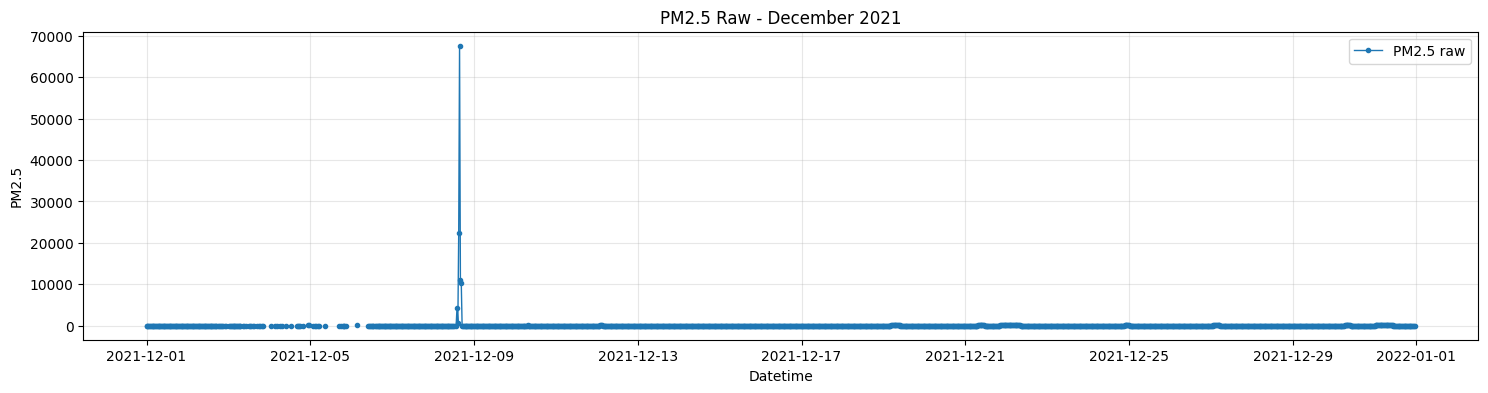

In [ ]:
plt.figure(figsize=(18, 4))

plt.plot(
    dec2021["datetime"],
    dec2021["pm25"],
    marker="o",
    linewidth=1,
    markersize=3,
    label="PM2.5 raw"
)

plt.title("PM2.5 Raw - December 2021")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Extreme Value Flagging

In [ ]:
PM25_HIGH_LIMIT = 400  # sesuaikan setelah lihat plot/top values

df_full["is_extreme_high_pm25"] = (
    df_full["pm25"].notna() &
    (df_full["pm25"] > PM25_HIGH_LIMIT)
).astype(int)

print("Extreme high PM2.5 points:", df_full["is_extreme_high_pm25"].sum())

df_full[df_full["is_extreme_high_pm25"] == 1][
    ["datetime", "pm25", "label_eval", "source_file"]
].sort_values("pm25", ascending=False).head(50)

Extreme high PM2.5 points: 6


,datetime,pm25,label_eval,source_file
16399,2021-12-08 15:30:00,67601.0,1.0,2021_12.xlsx
16398,2021-12-08 15:00:00,22284.0,1.0,2021_12.xlsx
16400,2021-12-08 16:00:00,11001.0,1.0,2021_12.xlsx
16401,2021-12-08 16:30:00,10425.0,1.0,2021_12.xlsx
16396,2021-12-08 14:00:00,4309.0,1.0,2021_12.xlsx
16397,2021-12-08 14:30:00,640.0,1.0,2021_12.xlsx


In [ ]:
extreme_high_summary = (
    df_full[df_full["is_extreme_high_pm25"] == 1]
    .assign(year=lambda x: x["datetime"].dt.year,
            month=lambda x: x["datetime"].dt.month)
    .groupby(["year", "month"])
    .agg(
        n_points=("datetime", "size"),
        min_value=("pm25", "min"),
        max_value=("pm25", "max"),
        anomaly_count=("label_eval", "sum")
    )
    .reset_index()
)

extreme_high_summary

,year,month,n_points,min_value,max_value,anomaly_count
0,2021,12,6,640.0,67601.0,6.0


# Handling Extreme High and Statics

In [ ]:
df_full["pm25_clean"] = df_full["pm25"]

# 1. Missing timestamp tetap NaN
df_full.loc[df_full["is_missing_timestamp"] == 1, "pm25_clean"] = np.nan

# 2. Static zero panjang: semua titik dijadikan NaN
df_full.loc[df_full["is_zero_flatline"] == 1, "pm25_clean"] = np.nan

# 3. Static non-zero panjang: hanya titik ke-5 dst yang dijadikan NaN
nonzero_flat_tail_mask = (
    (df_full["is_nonzero_flatline"] == 1) &
    (df_full["flat_pos_in_run"] > STATIC_NONZERO_LIMIT)
)

df_full.loc[nonzero_flat_tail_mask, "pm25_clean"] = np.nan

# Flag titik non-zero flatline yang dipotong
df_full["is_nonzero_flatline_tail_removed"] = nonzero_flat_tail_mask.astype(int)

# 4. Extreme high sensor artifact dijadikan NaN
df_full.loc[df_full["is_extreme_high_pm25"] == 1, "pm25_clean"] = np.nan

# Label evaluasi bersih:
# titik yang pm25_clean NaN tidak ikut evaluasi
df_full["label_eval_clean"] = df_full["label_eval"]
df_full.loc[df_full["pm25_clean"].isna(), "label_eval_clean"] = np.nan

# Semua titik yang tidak bisa dipakai model/evaluasi
df_full["is_invalid_pm25"] = df_full["pm25_clean"].isna().astype(int)

print("NaN pm25 raw:", df_full["pm25"].isna().sum())
print("NaN pm25_clean:", df_full["pm25_clean"].isna().sum())
print("Zero flatline converted to NaN:", df_full["is_zero_flatline"].sum())
print("Non-zero flatline total points:", df_full["is_nonzero_flatline"].sum())
print("Non-zero flatline tail converted to NaN:", df_full["is_nonzero_flatline_tail_removed"].sum())
print("Extreme high converted to NaN:", df_full["is_extreme_high_pm25"].sum())

NaN pm25 raw: 1590
NaN pm25_clean: 2124
Zero flatline converted to NaN: 57
Non-zero flatline total points: 1347
Non-zero flatline tail converted to NaN: 471
Extreme high converted to NaN: 6


In [ ]:
print(
    "NaN raw PM2.5:",
    df_full["pm25"].isna().sum()
)

print(
    "NaN clean PM2.5:",
    df_full["pm25_clean"].isna().sum()
)

print(
    "Missing timestamps:",
    df_full["is_missing_timestamp"].sum()
)

NaN raw PM2.5: 1590
NaN clean PM2.5: 2124
Missing timestamps: 1590


In [ ]:
df_full["year"] = df_full["datetime"].dt.year
df_full["month"] = df_full["datetime"].dt.month

summary_month = (
    df_full
    .groupby(["year", "month"])
    .agg(
        expected_rows=("datetime", "size"),
        observed_rows=("is_missing_timestamp", lambda x: (x == 0).sum()),
        missing_timestamp=("is_missing_timestamp", "sum"),
        long_gap_points=("is_long_gap", "sum"),

        zero_flatline_points=("is_zero_flatline", "sum"),
        nonzero_flatline_points=("is_nonzero_flatline", "sum"),
        nonzero_flatline_tail_removed=("is_nonzero_flatline_tail_removed", "sum"),

        extreme_high_points=("is_extreme_high_pm25", "sum"),

        invalid_pm25_points=("is_invalid_pm25", "sum"),
        anomaly_count=("label_eval_clean", "sum"),

        pm25_min=("pm25", "min"),
        pm25_max=("pm25", "max"),
        pm25_clean_nan=("pm25_clean", lambda x: x.isna().sum())
    )
    .reset_index()
)

summary_month["missing_pct"] = (
    summary_month["missing_timestamp"] / summary_month["expected_rows"] * 100
)

summary_month["invalid_pm25_pct"] = (
    summary_month["invalid_pm25_points"] / summary_month["expected_rows"] * 100
)

summary_month

,year,month,expected_rows,observed_rows,missing_timestamp,long_gap_points,zero_flatline_points,nonzero_flatline_points,nonzero_flatline_tail_removed,extreme_high_points,invalid_pm25_points,anomaly_count,pm25_min,pm25_max,pm25_clean_nan,missing_pct,invalid_pm25_pct
0,2021,1,1488,1442,46,46,0,59,11,0,57,0.0,1.0,132.0,57,3.091398,3.830645
1,2021,2,1344,1338,6,0,0,65,13,0,19,0.0,2.0,106.0,19,0.446429,1.413690
2,2021,3,1488,1488,0,0,0,34,3,0,3,0.0,3.0,144.0,3,0.000000,0.201613
3,2021,4,1440,1374,66,65,0,13,0,0,66,18.0,1.0,203.0,66,4.583333,4.583333
4,2021,5,1488,1465,23,21,0,21,1,0,24,0.0,5.0,138.0,24,1.545699,1.612903
5,2021,6,1440,1408,32,31,0,8,0,0,32,3.0,5.0,167.0,32,2.222222,2.222222
6,2021,7,1488,1473,15,0,0,8,0,0,15,3.0,0.0,207.0,15,1.008065,1.008065
7,2021,8,1488,1416,72,70,0,20,0,0,72,0.0,4.0,146.0,72,4.838710,4.838710
8,2021,9,1440,1413,27,16,0,27,3,0,30,0.0,4.0,112.0,30,1.875000,2.083333
9,2021,10,1488,1483,5,0,0,18,2,0,7,3.0,5.0,167.0,7,0.336022,0.470430


In [ ]:
missing_runs = (
    df_full[df_full["is_missing_timestamp"] == 1]
    .groupby("missing_run_id")
    .agg(
        start=("datetime", "min"),
        end=("datetime", "max"),
        n_points=("datetime", "size"),
        missing_run_len=("missing_run_len", "max")
    )
    .reset_index()
)

if not missing_runs.empty:
    missing_runs["duration_hours"] = missing_runs["n_points"] * 0.5
    missing_runs["gap_type"] = np.where(
        missing_runs["n_points"] > SHORT_GAP_LIMIT,
        "long_gap",
        "short_gap"
    )

missing_runs = missing_runs.sort_values("missing_run_id", ascending=True)

missing_runs

,missing_run_id,start,end,n_points,missing_run_len,duration_hours,gap_type
0,1.0,2021-01-22 13:30:00,2021-01-23 12:00:00,46,46,23.0,long_gap
1,2.0,2021-02-20 11:00:00,2021-02-20 11:30:00,2,2,1.0,short_gap
2,3.0,2021-02-24 12:30:00,2021-02-24 13:30:00,3,3,1.5,short_gap
3,4.0,2021-02-24 14:30:00,2021-02-24 14:30:00,1,1,0.5,short_gap
4,5.0,2021-04-03 03:30:00,2021-04-04 11:30:00,65,65,32.5,long_gap
...,...,...,...,...,...,...,...
110,111.0,2023-10-15 08:30:00,2023-10-15 08:30:00,1,1,0.5,short_gap
111,112.0,2023-11-25 11:00:00,2023-11-26 09:30:00,46,46,23.0,long_gap
112,113.0,2023-12-01 21:30:00,2023-12-01 23:00:00,4,4,2.0,short_gap
113,114.0,2023-12-24 14:00:00,2023-12-24 14:00:00,1,1,0.5,short_gap


In [ ]:
gap_event_summary = (
    missing_runs["gap_type"]
    .value_counts()
    .rename_axis("gap_type")
    .reset_index(name="n_gap_events")
)

display(gap_event_summary)

,gap_type,n_gap_events
0,short_gap,85
1,long_gap,30


In [ ]:
flatline_runs = (
    df_full[df_full["is_long_flatline"] == 1]
    .groupby("flat_run_id")
    .agg(
        start=("datetime", "min"),
        end=("datetime", "max"),
        n_points=("datetime", "size"),
        pm25_value=("pm25", "first"),
        label_sum_raw=("label_eval", "sum"),
        label_sum_clean=("label_eval_clean", "sum"),
        n_clean_kept=("pm25_clean", lambda x: x.notna().sum()),
        n_clean_nan=("pm25_clean", lambda x: x.isna().sum()),
        is_zero_flatline=("is_zero_flatline", "max"),
        is_nonzero_flatline=("is_nonzero_flatline", "max"),
        tail_removed=("is_nonzero_flatline_tail_removed", "sum")
    )
    .reset_index()
)

if not flatline_runs.empty:
    flatline_runs["duration_hours"] = flatline_runs["n_points"] * 0.5

    flatline_runs["flatline_type"] = np.select(
        [
            flatline_runs["is_zero_flatline"] == 1,
            flatline_runs["is_nonzero_flatline"] == 1
        ],
        [
            "zero_flatline",
            "nonzero_flatline"
        ],
        default="other"
    )

flatline_runs = flatline_runs.sort_values("n_points", ascending=False)

flatline_runs.head(30)

,flat_run_id,start,end,n_points,pm25_value,label_sum_raw,label_sum_clean,n_clean_kept,n_clean_nan,is_zero_flatline,is_nonzero_flatline,tail_removed,duration_hours,flatline_type
117,19784.0,2022-04-19 10:00:00,2022-04-26 20:30:00,358,27.0,0.0,0.0,4,354,0,1,354,179.0,nonzero_flatline
213,42213.0,2023-09-30 14:00:00,2023-10-01 09:30:00,40,0.0,0.0,0.0,0,40,1,0,0,20.0,zero_flatline
120,20187.0,2022-05-06 17:00:00,2022-05-06 21:30:00,10,6.0,0.0,0.0,4,6,0,1,6,5.0,nonzero_flatline
6,483.0,2021-01-13 11:00:00,2021-01-13 14:30:00,8,5.0,0.0,0.0,4,4,0,1,4,4.0,nonzero_flatline
97,16844.0,2022-02-07 14:00:00,2022-02-07 17:30:00,8,7.0,0.0,0.0,4,4,0,1,4,4.0,nonzero_flatline
63,13101.0,2021-11-07 21:30:00,2021-11-08 01:00:00,8,10.0,0.0,0.0,4,4,0,1,4,4.0,nonzero_flatline
24,2272.0,2021-02-28 11:30:00,2021-02-28 15:00:00,8,7.0,0.0,0.0,4,4,0,1,4,4.0,nonzero_flatline
91,16331.0,2022-01-26 01:00:00,2022-01-26 04:00:00,7,7.0,0.0,0.0,4,3,0,1,3,3.5,nonzero_flatline
121,20371.0,2022-05-11 04:00:00,2022-05-11 07:00:00,7,8.0,0.0,0.0,4,3,0,1,3,3.5,nonzero_flatline
15,1747.0,2021-02-14 14:30:00,2021-02-14 17:30:00,7,10.0,0.0,0.0,4,3,0,1,3,3.5,nonzero_flatline


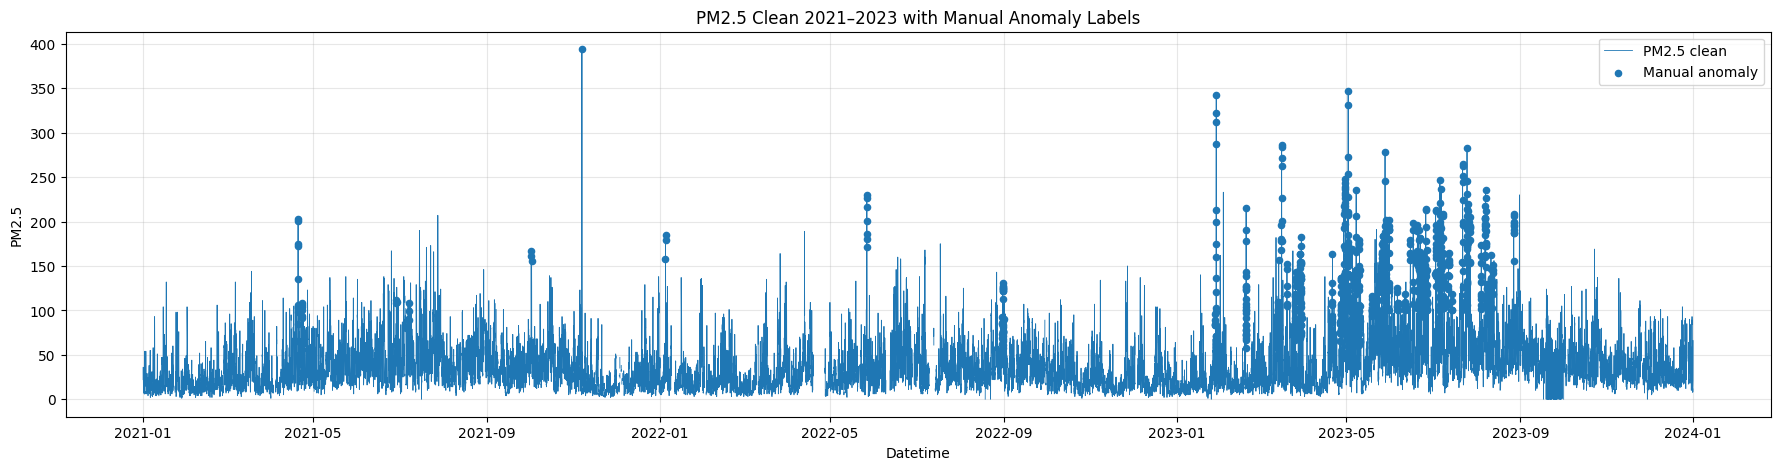

In [ ]:
df_plot = df_full.copy()

plt.figure(figsize=(22, 5))

plt.plot(
    df_plot["datetime"],
    df_plot["pm25_clean"],
    linewidth=0.6,
    label="PM2.5 clean"
)

anom = df_plot[df_plot["label_eval_clean"] == 1]

plt.scatter(
    anom["datetime"],
    anom["pm25_clean"],
    s=20,
    label="Manual anomaly",
    zorder=3
)

plt.title("PM2.5 Clean 2021–2023 with Manual Anomaly Labels")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

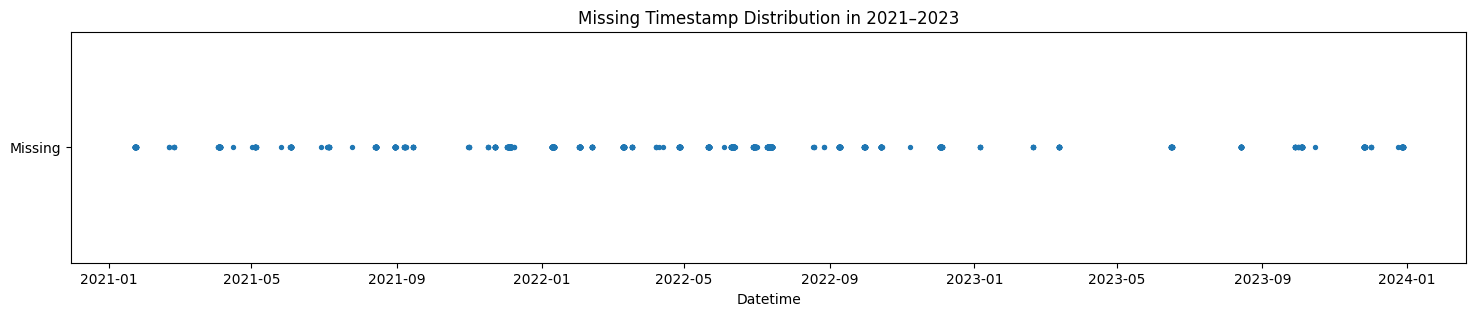

In [ ]:
plt.figure(figsize=(18, 3))

missing_points = df_full[df_full["is_missing_timestamp"] == 1]

plt.scatter(
    missing_points["datetime"],
    missing_points["is_missing_timestamp"],
    s=8
)

plt.title("Missing Timestamp Distribution in 2021–2023")
plt.xlabel("Datetime")
plt.yticks([1], ["Missing"])
plt.show()

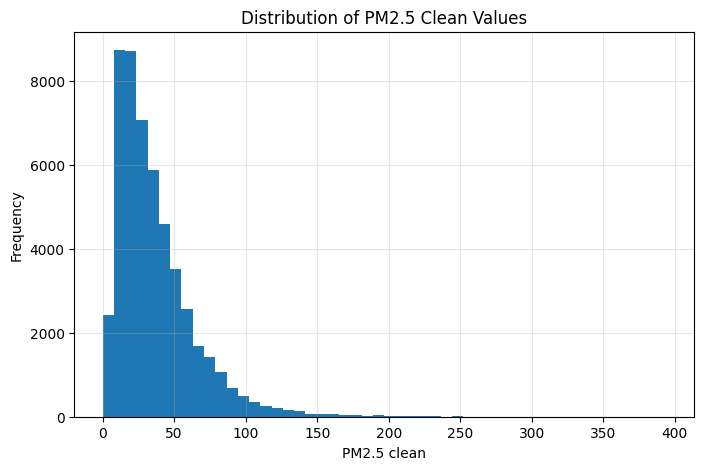

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_full["pm25_clean"].dropna(), bins=50)
plt.title("Distribution of PM2.5 Clean Values")
plt.xlabel("PM2.5 clean")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

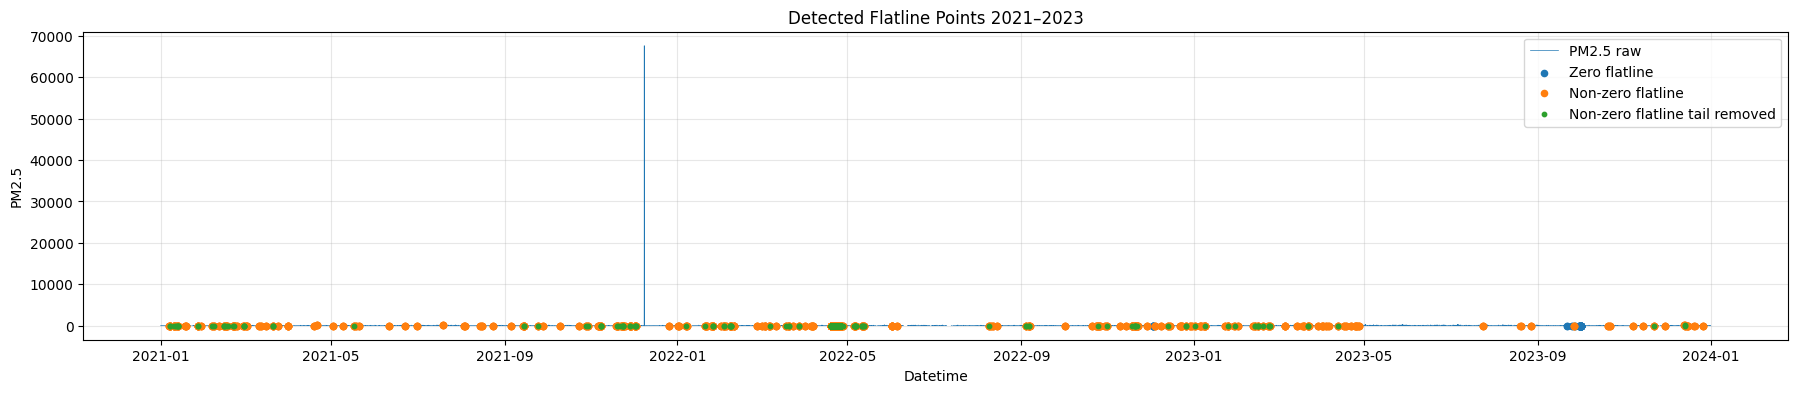

In [ ]:
plt.figure(figsize=(22, 4))

plt.plot(
    df_full["datetime"],
    df_full["pm25"],
    linewidth=0.5,
    label="PM2.5 raw"
)

zero_flat = df_full[df_full["is_zero_flatline"] == 1]
nonzero_flat = df_full[df_full["is_nonzero_flatline"] == 1]
tail_removed = df_full[df_full["is_nonzero_flatline_tail_removed"] == 1]

plt.scatter(
    zero_flat["datetime"],
    zero_flat["pm25"],
    s=20,
    label="Zero flatline",
    zorder=3
)

plt.scatter(
    nonzero_flat["datetime"],
    nonzero_flat["pm25"],
    s=20,
    label="Non-zero flatline",
    zorder=3
)

plt.scatter(
    tail_removed["datetime"],
    tail_removed["pm25"],
    s=10,
    label="Non-zero flatline tail removed",
    zorder=4
)

plt.title("Detected Flatline Points 2021–2023")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Split

In [ ]:
train = df_full[
    (df_full["datetime"] >= "2021-01-01") &
    (df_full["datetime"] < "2022-11-01")
].copy()

val = df_full[
    (df_full["datetime"] >= "2022-11-01") &
    (df_full["datetime"] < "2023-06-01")
].copy()

test = df_full[
    (df_full["datetime"] >= "2023-06-01") &
    (df_full["datetime"] < "2024-01-01")
].copy()

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "start": [train["datetime"].min(), val["datetime"].min(), test["datetime"].min()],
    "end": [train["datetime"].max(), val["datetime"].max(), test["datetime"].max()],
    "rows": [len(train), len(val), len(test)],

    "observed_rows": [
        (train["is_missing_timestamp"] == 0).sum(),
        (val["is_missing_timestamp"] == 0).sum(),
        (test["is_missing_timestamp"] == 0).sum()
    ],

    "missing_timestamp": [
        train["is_missing_timestamp"].sum(),
        val["is_missing_timestamp"].sum(),
        test["is_missing_timestamp"].sum()
    ],

    "missing_pct": [
        train["is_missing_timestamp"].mean() * 100,
        val["is_missing_timestamp"].mean() * 100,
        test["is_missing_timestamp"].mean() * 100
    ],

    "long_gap_points": [
        train["is_long_gap"].sum(),
        val["is_long_gap"].sum(),
        test["is_long_gap"].sum()
    ],

    "zero_flatline_points": [
        train["is_zero_flatline"].sum(),
        val["is_zero_flatline"].sum(),
        test["is_zero_flatline"].sum()
    ],

    "nonzero_flatline_points": [
        train["is_nonzero_flatline"].sum(),
        val["is_nonzero_flatline"].sum(),
        test["is_nonzero_flatline"].sum()
    ],

    "nonzero_flatline_tail_removed": [
        train["is_nonzero_flatline_tail_removed"].sum(),
        val["is_nonzero_flatline_tail_removed"].sum(),
        test["is_nonzero_flatline_tail_removed"].sum()
    ],

    "invalid_pm25_points": [
        train["is_invalid_pm25"].sum(),
        val["is_invalid_pm25"].sum(),
        test["is_invalid_pm25"].sum()
    ],

    "invalid_pm25_pct": [
        train["is_invalid_pm25"].mean() * 100,
        val["is_invalid_pm25"].mean() * 100,
        test["is_invalid_pm25"].mean() * 100
    ],

    "anomaly_count": [
        train["label_eval_clean"].sum(skipna=True),
        val["label_eval_clean"].sum(skipna=True),
        test["label_eval_clean"].sum(skipna=True)
    ],
    "extreme_high_points": [
        train["is_extreme_high_pm25"].sum(),
        val["is_extreme_high_pm25"].sum(),
        test["is_extreme_high_pm25"].sum()
    ],
})

split_summary

,split,start,end,rows,observed_rows,missing_timestamp,missing_pct,long_gap_points,zero_flatline_points,nonzero_flatline_points,nonzero_flatline_tail_removed,invalid_pm25_points,invalid_pm25_pct,anomaly_count,extreme_high_points
0,train,2021-01-01,2022-10-31 23:30:00,32112,30827,1285,4.001619,1100,0,1023,443,1734,5.399851,67.0,6
1,val,2022-11-01,2023-05-31 23:30:00,10176,10069,107,1.051494,94,6,257,25,138,1.356132,482.0,0
2,test,2023-06-01,2023-12-31 23:30:00,10272,10074,198,1.927570,178,51,67,3,252,2.453271,368.0,0


In [ ]:
# Pilih kolom yang ingin dianalisis:
# "pm25"       = data mentah
# "pm25_clean" = setelah cleaning
VALUE_COL = "pm25"

raw_pm25_df = df_full[
    df_full["datetime"].dt.year.isin([2021, 2022, 2023])
].copy()

raw_pm25_df["year"] = raw_pm25_df["datetime"].dt.year

summary_raw = (
    raw_pm25_df
    .groupby("year")[VALUE_COL]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

display(summary_raw)

,count,mean,std,min,50%,90%,95%,99%,99.5%,99.9%,max
year,,,,,,,,,,,
2021,17086.0,40.944106,557.848551,0.0,28.0,67.0,82.0,118.0,131.0,171.915,67601.0
2022,16591.0,30.632753,22.873146,0.0,25.0,61.0,76.0,111.0,126.0,162.230,230.0
2023,17293.0,44.388250,33.978526,0.0,36.0,84.0,109.0,175.0,196.0,247.708,347.0


In [ ]:
#for year in [2021, 2022, 2023]:
print(f"\nTop 20 raw PM2.5 values")

display(
        raw_pm25_df.loc[
            raw_pm25_df["datetime"].dt.year.isin([2021, 2022, 2023])
        ][["datetime", VALUE_COL]]
        .dropna()
        .sort_values(
            VALUE_COL,
            ascending=False
        )
        .head(20)
    )


Top 20 raw PM2.5 values


,datetime,pm25
16399,2021-12-08 15:30:00,67601.0
16398,2021-12-08 15:00:00,22284.0
16400,2021-12-08 16:00:00,11001.0
16401,2021-12-08 16:30:00,10425.0
16396,2021-12-08 14:00:00,4309.0
16397,2021-12-08 14:30:00,640.0
14878,2021-11-06 23:00:00,394.0
40860,2023-05-02 06:00:00,347.0
36387,2023-01-29 01:30:00,342.0
40861,2023-05-02 06:30:00,331.0


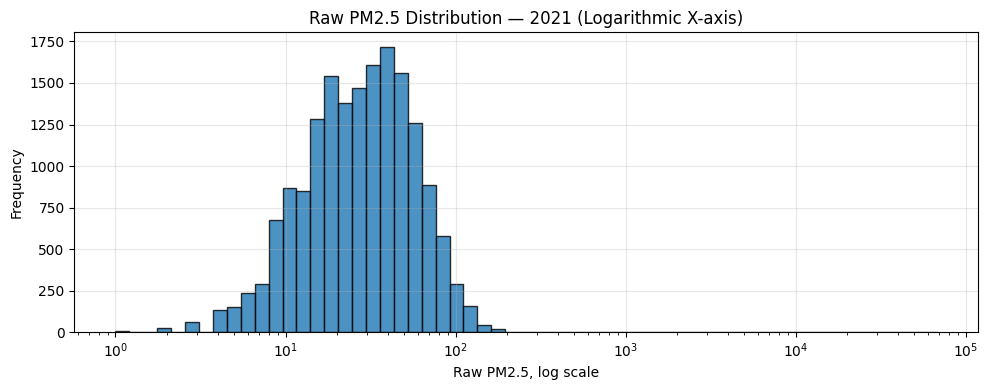

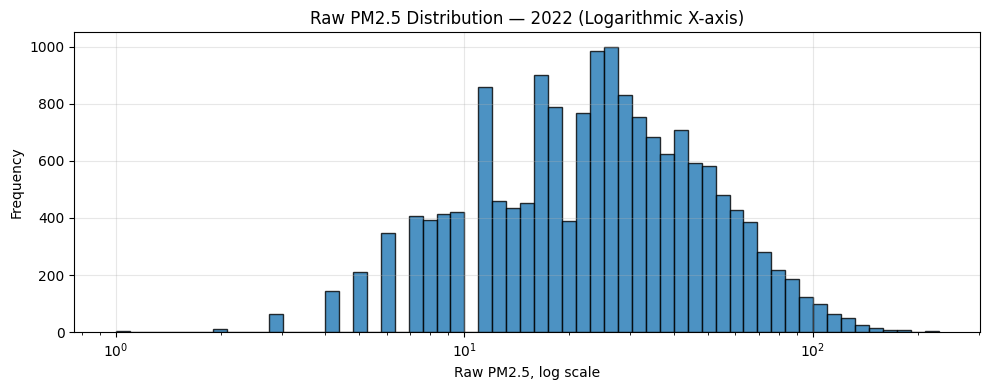

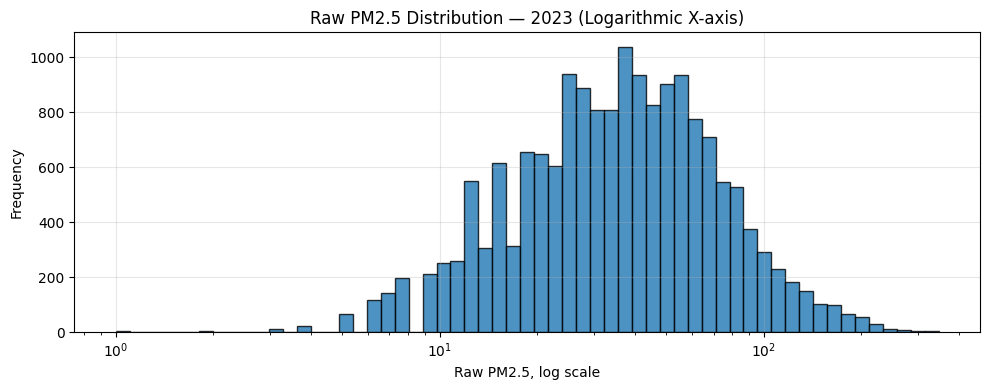

In [ ]:
for year in [2021, 2022, 2023]:
    year_values = raw_pm25_df.loc[
        raw_pm25_df["year"] == year,
        VALUE_COL
    ].dropna()

    # Log scale hanya bisa untuk nilai positif
    positive_values = year_values[
        year_values > 0
    ]

    log_bins = np.logspace(
        np.log10(positive_values.min()),
        np.log10(positive_values.max()),
        60
    )

    plt.figure(figsize=(10, 4))

    plt.hist(
        positive_values,
        bins=log_bins,
        edgecolor="black",
        alpha=0.8
    )

    plt.xscale("log")

    plt.title(
        f"Raw PM2.5 Distribution — {year} "
        "(Logarithmic X-axis)"
    )
    plt.xlabel("Raw PM2.5, log scale")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

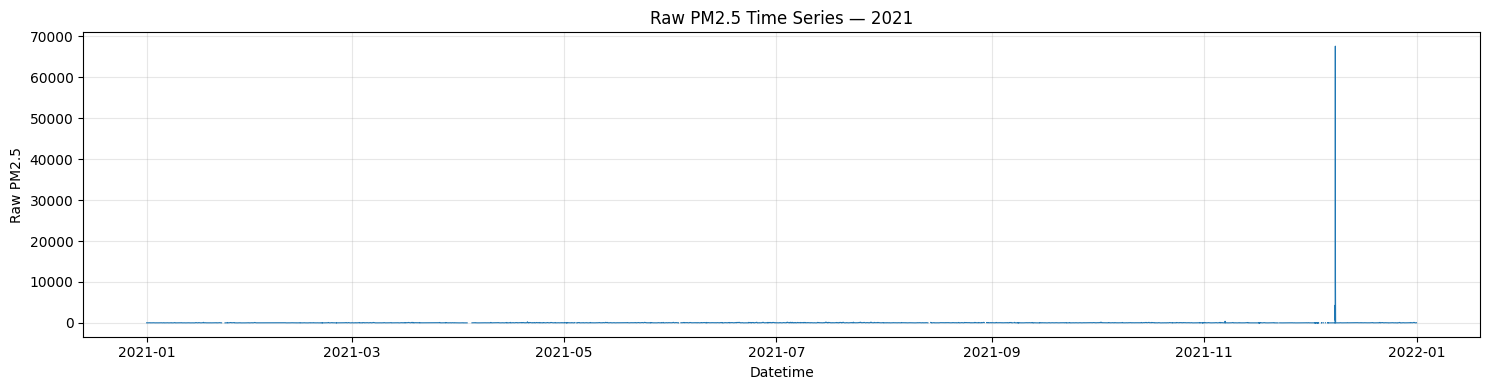

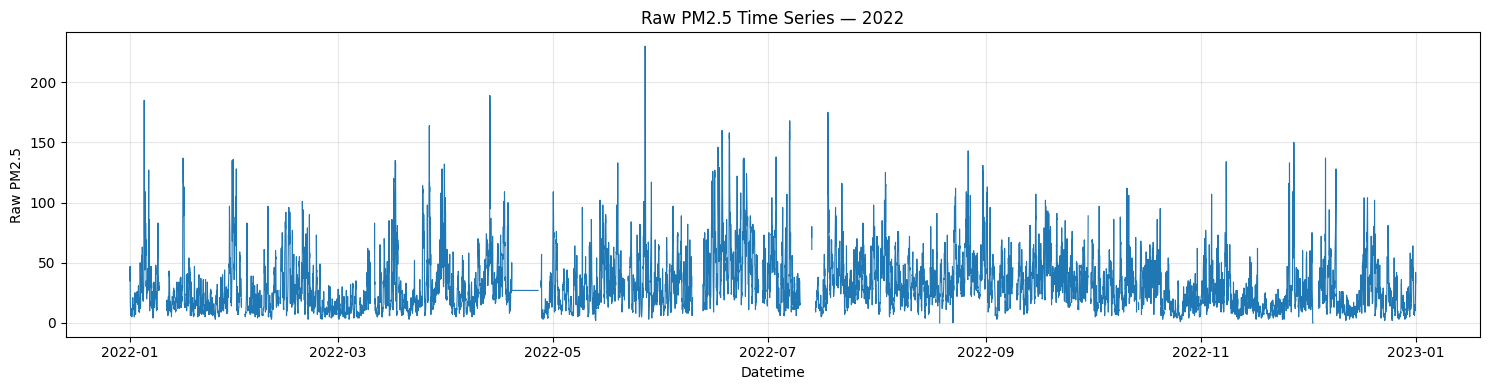

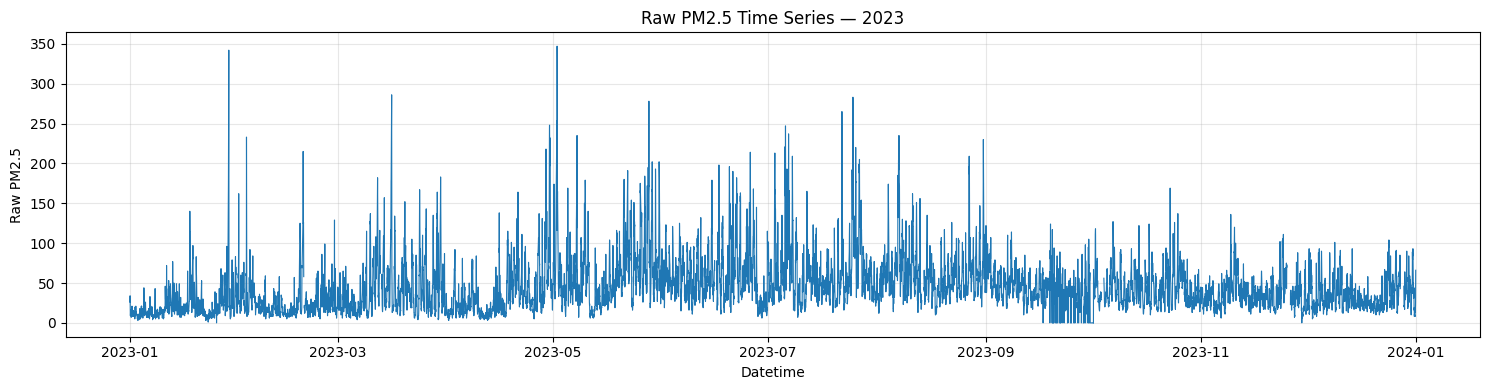

In [ ]:
for year in [2021, 2022, 2023]:
    year_df = raw_pm25_df[
        raw_pm25_df["year"] == year
    ]

    plt.figure(figsize=(15, 4))

    plt.plot(
        year_df["datetime"],
        year_df[VALUE_COL],
        linewidth=0.8
    )

    plt.title(
        f"Raw PM2.5 Time Series — {year}"
    )
    plt.xlabel("Datetime")
    plt.ylabel("Raw PM2.5")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

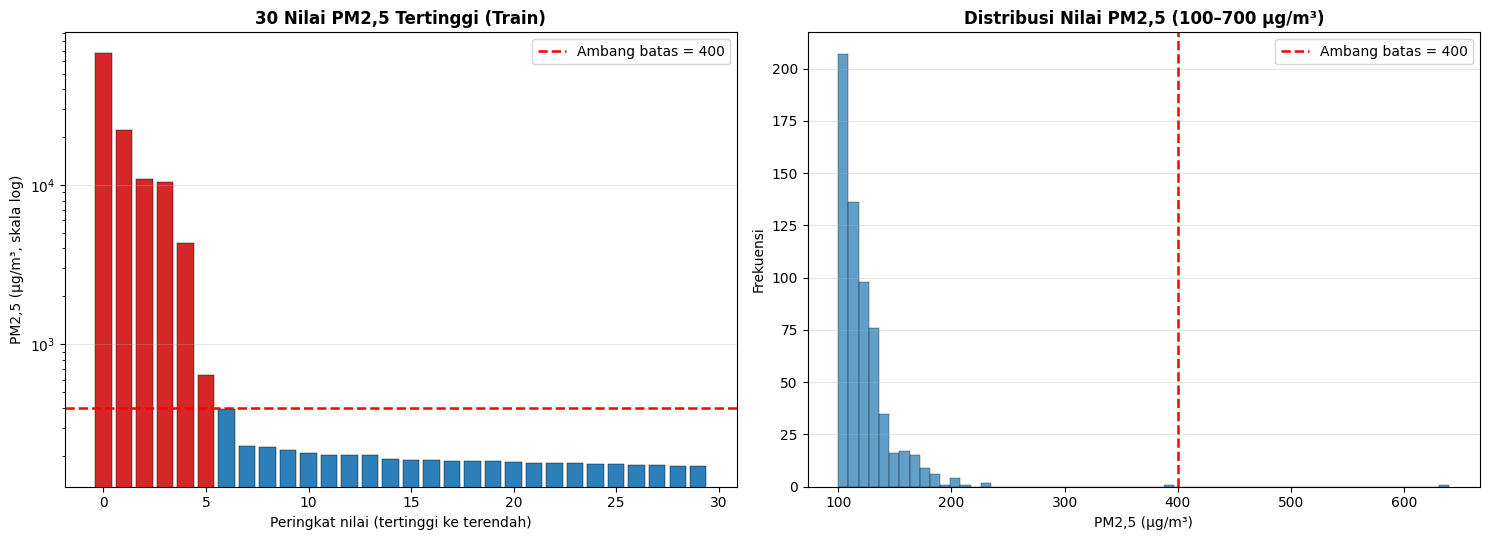

In [ ]:
raw = train['pm25'].dropna()   # sesuaikan nama dataframe jika berbeda
EXTREME_LIMIT = 400

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- KIRI: 30 nilai tertinggi (skala log) ---
ax = axes[0]
top = raw.sort_values(ascending=False).head(30).reset_index(drop=True)
colors = ['#d62728' if v > EXTREME_LIMIT else '#2c7fb8' for v in top]
ax.bar(range(len(top)), top.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axhline(EXTREME_LIMIT, color='red', linestyle='--', linewidth=1.8,
           label=f'Ambang batas = {EXTREME_LIMIT}')
ax.set_yscale('log')
ax.set_title('30 Nilai PM2,5 Tertinggi (Train)', fontsize=12, fontweight='bold')
ax.set_xlabel('Peringkat nilai (tertinggi ke terendah)')
ax.set_ylabel('PM2,5 (μg/m³, skala log)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# --- KANAN: histogram zoom rentang menengah ---
ax = axes[1]
zoom = raw[(raw >= 100) & (raw <= 700)]
ax.hist(zoom, bins=60, color='#2c7fb8', alpha=0.75, edgecolor='black', linewidth=0.3)
ax.axvline(EXTREME_LIMIT, color='red', linestyle='--', linewidth=1.8,
           label=f'Ambang batas = {EXTREME_LIMIT}')
ax.set_title('Distribusi Nilai PM2,5 (100–700 μg/m³)', fontsize=12, fontweight='bold')
ax.set_xlabel('PM2,5 (μg/m³)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

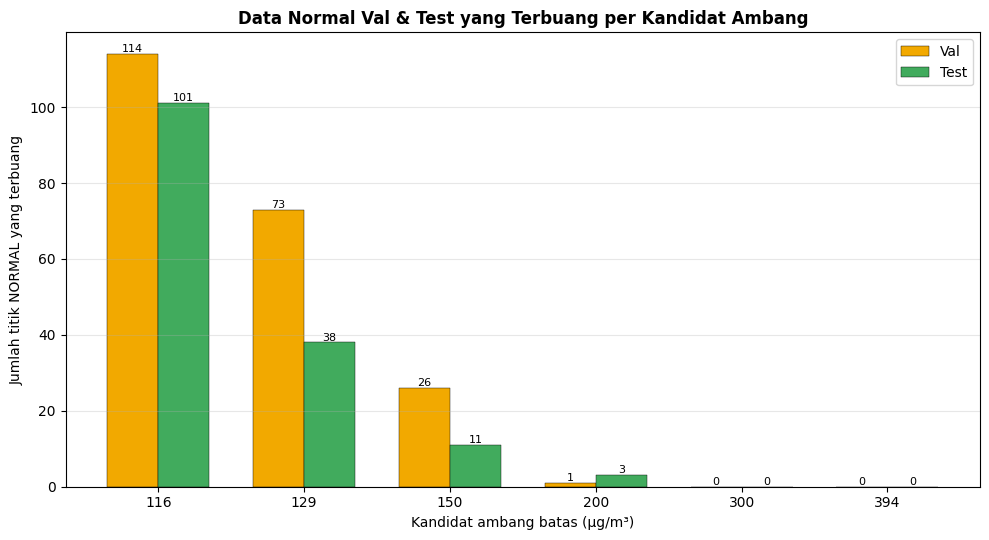

In [ ]:
thresholds = [116, 129, 150, 200, 300, 394]
val_lost, test_lost = [], []
for thr in thresholds:
    v = val[val['pm25'] > thr].dropna(subset=['label_eval_clean'])
    t = test[test['pm25'] > thr].dropna(subset=['label_eval_clean'])
    val_lost.append(int((v['label_eval_clean'] == 0).sum()))
    test_lost.append(int((t['label_eval_clean'] == 0).sum()))

x = np.arange(len(thresholds)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, val_lost, w, label='Val', color='#f2a900', edgecolor='black', linewidth=0.3)
ax.bar(x + w/2, test_lost, w, label='Test', color='#41ab5d', edgecolor='black', linewidth=0.3)
for i, (vl, tl) in enumerate(zip(val_lost, test_lost)):
    ax.text(i - w/2, vl + 0.5, str(vl), ha='center', fontsize=8)
    ax.text(i + w/2, tl + 0.5, str(tl), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel('Kandidat ambang batas (μg/m³)')
ax.set_ylabel('Jumlah titik NORMAL yang terbuang')
ax.set_title('Data Normal Val & Test yang Terbuang per Kandidat Ambang', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
splits = {'Train': train, 'Val': val, 'Test': test}

rows = []
for name, df in splits.items():
    rows.append({
        'Split': name,
        'Jumlah Baris': len(df),
        'Minimum Datetime': df['datetime'].min(),
        'Maximum Datetime': df['datetime'].max(),
        'Label 0 (Normal)': int((df['label_eval_clean'] == 0).sum()),
        'Label 1 (Invalid/Anomali)': int((df['label_eval_clean'] == 1).sum()),
    })

desc_df = pd.DataFrame(rows)
display(desc_df)

,Split,Jumlah Baris,Minimum Datetime,Maximum Datetime,Label 0 (Normal),Label 1 (Invalid/Anomali)
0,Train,32112,2021-01-01,2022-10-31 23:30:00,30311,67
1,Val,10176,2022-11-01,2023-05-31 23:30:00,9556,482
2,Test,10272,2023-06-01,2023-12-31 23:30:00,9652,368


In [71]:
print(sorted(long_runs["missing_run_id"].unique()))
print(sorted(short_runs["missing_run_id"].unique()))

[1.0, 5.0, 8.0, 10.0, 21.0, 22.0, 24.0, 36.0, 66.0, 74.0, 75.0, 76.0, 77.0, 82.0, 83.0, 85.0, 86.0, 90.0, 91.0, 97.0, 98.0, 99.0, 100.0, 102.0, 105.0, 106.0, 107.0, 110.0, 112.0, 115.0]
[2.0, 3.0, 4.0, 6.0, 7.0, 9.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 23.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 78.0, 79.0, 80.0, 81.0, 84.0, 87.0, 88.0, 89.0, 92.0, 93.0, 94.0, 95.0, 96.0, 101.0, 103.0, 104.0, 108.0, 109.0, 111.0, 113.0, 114.0]


=== SHORT GAP (<= 12 titik) — 85 run ===


,missing_run_id,gap_len,waktu_mulai,waktu_selesai
70,71.0,12,2021-12-06 04:00:00,2021-12-06 09:30:00
69,70.0,12,2021-12-05 21:30:00,2021-12-06 03:00:00
87,88.0,11,2022-06-30 14:00:00,2022-06-30 19:00:00
77,78.0,10,2022-03-18 04:00:00,2022-03-18 08:30:00
107,108.0,10,2023-09-28 11:00:00,2023-09-28 15:30:00
48,49.0,9,2021-12-03 20:30:00,2021-12-04 00:30:00
26,27.0,9,2021-09-14 13:30:00,2021-09-14 17:30:00
102,103.0,6,2023-01-05 13:30:00,2023-01-05 16:00:00
64,65.0,6,2021-12-05 05:30:00,2021-12-05 08:00:00
103,104.0,6,2023-02-19 08:30:00,2023-02-19 11:00:00


=== LONG GAP (> 12 titik) — 30 run ===


,missing_run_id,gap_len,waktu_mulai,waktu_selesai
99,100.0,15,2022-10-14 08:30:00,2022-10-14 15:30:00
75,76.0,15,2022-02-12 07:30:00,2022-02-12 14:30:00
23,24.0,16,2021-09-07 01:00:00,2021-09-07 08:30:00
65,66.0,16,2021-12-05 09:00:00,2021-12-05 16:30:00
104,105.0,17,2023-03-13 01:30:00,2023-03-13 09:30:00
35,36.0,20,2021-11-22 05:30:00,2021-11-22 15:00:00
7,8.0,21,2021-05-04 03:30:00,2021-05-04 13:30:00
98,99.0,22,2022-10-13 19:30:00,2022-10-14 06:00:00
106,107.0,27,2023-08-13 19:00:00,2023-08-14 08:00:00
105,106.0,27,2023-06-16 00:00:00,2023-06-16 13:00:00


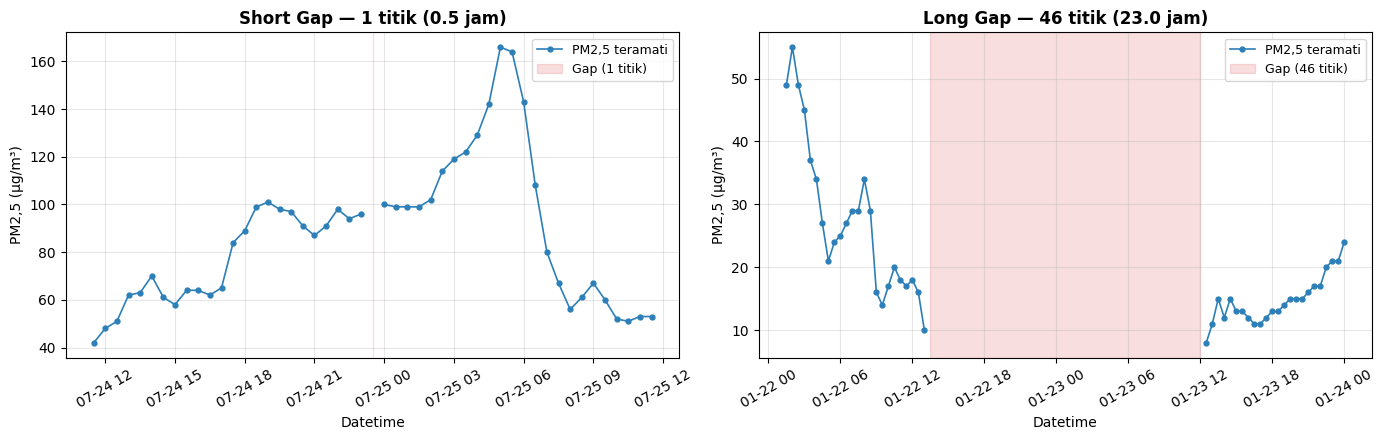

Short Gap: run_id=20, 1 titik, 2021-07-24 23:30:00 s/d 2021-07-24 23:30:00
Long Gap: run_id=1, 46 titik, 2021-01-22 13:30:00 s/d 2021-01-23 12:00:00


In [80]:
# =========================================================
# Contoh Visual Short Gap dan Long Gap (pilih run sendiri)
# =========================================================
import matplotlib.pyplot as plt

# ---------- KONFIGURASI ----------
SHORT_RUN_ID = 20# isi dengan missing_run_id pilihan, atau None = otomatis (terpanjang)
LONG_RUN_ID  = 1  # isi dengan missing_run_id pilihan, atau None = otomatis (terpendek)
CONTEXT      = 24     # titik konteks sebelum & sesudah gap (24 titik = 12 jam)
# ---------------------------------

# Ringkas setiap run missing menjadi satu baris
runs = (
    df_full[df_full["is_missing_timestamp"] == 1]
    .groupby("missing_run_id")
    .agg(gap_len=("missing_run_len", "first"),
         idx_start=("datetime", lambda s: s.index.min()),
         idx_end=("datetime", lambda s: s.index.max()),
         waktu_mulai=("datetime", "min"),
         waktu_selesai=("datetime", "max"))
    .reset_index()
)

short_runs = runs[runs["gap_len"] <= SHORT_GAP_LIMIT]
long_runs  = runs[runs["gap_len"] >  SHORT_GAP_LIMIT]

# Tampilkan daftar kandidat supaya bisa dipilih
print(f"=== SHORT GAP (<= {SHORT_GAP_LIMIT} titik) — {len(short_runs)} run ===")
display(short_runs[["missing_run_id", "gap_len", "waktu_mulai", "waktu_selesai"]]
        .sort_values("gap_len", ascending=False).head(20))

print(f"=== LONG GAP (> {SHORT_GAP_LIMIT} titik) — {len(long_runs)} run ===")
display(long_runs[["missing_run_id", "gap_len", "waktu_mulai", "waktu_selesai"]]
        .sort_values("gap_len").head(20))

# Pilih run yang akan diplot
def pilih_run(subset, run_id, fallback_ascending):
    if subset.empty:
        return None
    if run_id is not None:
        cocok = subset[subset["missing_run_id"] == run_id]
        if cocok.empty:
            raise ValueError(f"missing_run_id {run_id} tidak ada di kategori ini.")
        return cocok.iloc[0]
    return subset.sort_values("gap_len", ascending=fallback_ascending).iloc[0]

contoh = []
r_short = pilih_run(short_runs, SHORT_RUN_ID, fallback_ascending=False)
r_long  = pilih_run(long_runs,  LONG_RUN_ID,  fallback_ascending=True)
if r_short is not None:
    contoh.append(("Short Gap", r_short))
if r_long is not None:
    contoh.append(("Long Gap", r_long))

# Plot
fig, axes = plt.subplots(1, len(contoh), figsize=(7 * len(contoh), 4.5))
if len(contoh) == 1:
    axes = [axes]

for ax, (judul, run) in zip(axes, contoh):
    i0, i1 = int(run["idx_start"]), int(run["idx_end"])
    lo = max(0, i0 - CONTEXT)
    hi = min(len(df_full) - 1, i1 + CONTEXT)
    ctx = df_full.loc[lo:hi]

    ax.plot(ctx["datetime"], ctx["pm25"], marker="o", markersize=3.5,
            linewidth=1.2, color="#2c7fb8", label="PM2,5 teramati")
    ax.axvspan(df_full.loc[i0, "datetime"], df_full.loc[i1, "datetime"],
               color="#d62728", alpha=0.15,
               label=f"Gap ({int(run['gap_len'])} titik)")

    ax.set_title(f"{judul} — {int(run['gap_len'])} titik "
                 f"({int(run['gap_len']) * 0.5:.1f} jam)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Datetime")
    ax.set_ylabel("PM2,5 (μg/m³)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

for judul, run in contoh:
    print(f"{judul}: run_id={int(run['missing_run_id'])}, "
          f"{int(run['gap_len'])} titik, "
          f"{run['waktu_mulai']} s/d {run['waktu_selesai']}")

In [ ]:
output_dir = Path(r"D:\Kuliah\Tugas Akhir\TA\dataset\processed_pm25_2021_2023")
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

df_full.to_csv(output_dir / "pm25_2021_2023_full_clean.csv", index=False)

train.to_csv(output_dir / "pm25_2021_2023_train_clean.csv", index=False)
val.to_csv(output_dir / "pm25_2021_2023_val_clean.csv", index=False)
test.to_csv(output_dir / "pm25_2021_2023_test_clean.csv", index=False)

summary_month.to_csv(output_dir / "summary_month_2021_2023.csv", index=False)
missing_runs.to_csv(output_dir / "missing_runs_2021_2023.csv", index=False)
flatline_runs.to_csv(output_dir / "flatline_runs_2021_2023.csv", index=False)
split_summary.to_csv(output_dir / "split_summary_2021_2023.csv", index=False)

print(f"Files saved to: {output_dir.resolve()}")

Files saved to: D:\Kuliah\Tugas Akhir\TA\dataset\processed_pm25_2021_2023
